# HDBSCAN Parameter Persistence Analysis

Compute cluster persistence scores across parameter choices to identify robust structures.

In [8]:
import numpy as np
import h5py
import re
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

OUTPUT_DIR = Path("../output")
OVERLAP_THRESHOLD = 0.5  # Minimum Jaccard overlap to consider clusters "the same"

## 1. Load All Parameter Runs

In [9]:
def parse_filename(filename):
    """Extract (min_cluster_size, min_samples) from filename."""
    match = re.search(r'mcs_(\d+)_ms_(\d+)', filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def load_cluster_members(filepath):
    """Load cluster member indices from HDF5 file.
    
    Uses the global halo index from /assignments as the unique identifier.
    This is stable across runs since all use the same input data.
    """
    clusters = {}
    with h5py.File(filepath, 'r') as f:
        if 'assignments' not in f or 'label' not in f['assignments']:
            print(f"Warning: No assignments found in {filepath}")
            return clusters
        
        labels = f['assignments/label'][:]
        
        cluster_attrs = {}
        if 'clusters' in f:
            for cluster_name in f['clusters'].keys():
                cid = int(cluster_name.split('_')[1])
                grp = f[f'clusters/{cluster_name}']
                cluster_attrs[cid] = {
                    'existence_prob': grp.attrs.get('existence_prob', np.nan),
                    'center_xyz': grp.attrs.get('center_xyz', np.array([np.nan]*3)),
                    'mean_m200_mass': grp.attrs.get('mean_m200_mass', np.nan)
                }
        
        unique_labels = np.unique(labels)
        for label in unique_labels:
            if label == -1:
                continue
            member_indices = set(np.where(labels == label)[0])
            attrs = cluster_attrs.get(label, {})
            clusters[label] = {
                'members': member_indices,
                'n_members': len(member_indices),
                'existence_prob': attrs.get('existence_prob', np.nan),
                'center_xyz': attrs.get('center_xyz', np.array([np.nan]*3)),
                'mean_m200_mass': attrs.get('mean_m200_mass', np.nan)
            }
    return clusters

# Find all HDBSCAN output files
files = sorted(OUTPUT_DIR.glob("hdbscan_clusters_mcs_*_ms_*.h5"))
print(f"Found {len(files)} parameter runs")

# Load all runs
all_runs = {}
for f in files:
    mcs, ms = parse_filename(f.name)
    if mcs is not None:
        all_runs[(mcs, ms)] = load_cluster_members(f)

# Filter out degenerate runs (phase transition regime)
MIN_CLUSTERS = 100  # Runs with fewer clusters are likely degenerate
max_clusters = max(len(c) for c in all_runs.values())

runs = {}
excluded = []
for params, clusters in all_runs.items():
    n_clusters = len(clusters)
    if n_clusters >= MIN_CLUSTERS:
        runs[params] = clusters
    else:
        excluded.append((params, n_clusters))

print(f"\nFiltering runs with < {MIN_CLUSTERS} clusters:")
print(f"  Kept: {len(runs)} runs")
print(f"  Excluded: {len(excluded)} degenerate runs")
if excluded:
    print(f"  Excluded params: {[(p, n) for p, n in sorted(excluded)]}")

print(f"\nCluster counts in valid runs:")
for params in sorted(runs.keys()):
    print(f"  mcs={params[0]}, ms={params[1]}: {len(runs[params])} clusters")

if len(runs) < 2:
    raise ValueError("Need at least 2 valid parameter runs for persistence analysis")

Found 176 parameter runs

Filtering runs with < 100 clusters:
  Kept: 165 runs
  Excluded: 11 degenerate runs
  Excluded params: [((4, 17), 2), ((5, 17), 2), ((7, 17), 2), ((8, 17), 2), ((9, 17), 2), ((10, 17), 2), ((11, 17), 2), ((12, 17), 2), ((13, 17), 2), ((14, 17), 2), ((15, 17), 2)]

Cluster counts in valid runs:
  mcs=4, ms=5: 12832 clusters
  mcs=4, ms=6: 10637 clusters
  mcs=4, ms=7: 9137 clusters
  mcs=4, ms=8: 7902 clusters
  mcs=4, ms=9: 7065 clusters
  mcs=4, ms=10: 6382 clusters
  mcs=4, ms=11: 5850 clusters
  mcs=4, ms=12: 5356 clusters
  mcs=4, ms=13: 5018 clusters
  mcs=4, ms=14: 4653 clusters
  mcs=4, ms=15: 4381 clusters
  mcs=4, ms=16: 4177 clusters
  mcs=4, ms=18: 3733 clusters
  mcs=4, ms=19: 3593 clusters
  mcs=4, ms=20: 3396 clusters
  mcs=5, ms=5: 10950 clusters
  mcs=5, ms=6: 9245 clusters
  mcs=5, ms=7: 7953 clusters
  mcs=5, ms=8: 6948 clusters
  mcs=5, ms=9: 6261 clusters
  mcs=5, ms=10: 5634 clusters
  mcs=5, ms=11: 5227 clusters
  mcs=5, ms=12: 4825 clust

## 2. Match Clusters Across Runs

In [10]:
# FAST approach: inverted index to avoid unnecessary comparisons
# Key insight: two clusters can only match if they share at least one halo

def build_inverted_index(runs):
    """Build inverted index: halo_id -> list of (params, cluster_id)."""
    index = defaultdict(list)
    cluster_members = {}  # (params, cid) -> set of members
    cluster_sizes = {}    # (params, cid) -> size
    
    for params, clusters in runs.items():
        for cid, cdata in clusters.items():
            members = cdata['members']
            key = (params, cid)
            cluster_members[key] = members
            cluster_sizes[key] = len(members)
            for halo_id in members:
                index[halo_id].append(key)
    
    return index, cluster_members, cluster_sizes

def find_candidates(params, cid, members, inverted_index):
    """Find clusters in OTHER runs that share at least one halo."""
    candidates = defaultdict(set)  # other_params -> set of candidate cids
    for halo_id in members:
        for (other_params, other_cid) in inverted_index[halo_id]:
            if other_params != params:
                candidates[other_params].add(other_cid)
    return candidates

def jaccard_sets(set_a, set_b):
    """Compute Jaccard similarity between two sets."""
    intersection = len(set_a & set_b)
    union = len(set_a) + len(set_b) - intersection
    return intersection / union if union > 0 else 0.0

def precompute_all_matches_fast(runs, threshold=OVERLAP_THRESHOLD):
    """Precompute matches using inverted index (much faster)."""
    print("Building inverted index...")
    inverted_index, cluster_members, cluster_sizes = build_inverted_index(runs)
    print(f"  Index size: {len(inverted_index)} unique halos")
    
    matches = {}  # (from_params, to_params) -> {from_cid: (to_cid, jaccard) or None}
    param_list = list(runs.keys())
    
    # Initialize match dictionaries
    for p1 in param_list:
        for p2 in param_list:
            if p1 != p2:
                matches[(p1, p2)] = {}
    
    # Process each run
    total_clusters = sum(len(c) for c in runs.values())
    
    with tqdm(total=total_clusters, desc="Computing matches") as pbar:
        for params, clusters in runs.items():
            for cid, cdata in clusters.items():
                members = cdata['members']
                size_a = len(members)
                
                # Find candidate clusters in other runs
                candidates = find_candidates(params, cid, members, inverted_index)
                
                # For each other run, find best match among candidates
                for other_params in param_list:
                    if other_params == params:
                        continue
                    
                    best_jaccard = 0
                    best_match = None
                    
                    for other_cid in candidates.get(other_params, []):
                        other_members = cluster_members[(other_params, other_cid)]
                        size_b = len(other_members)
                        
                        # Size filter
                        if size_a > 2 * size_b or size_b > 2 * size_a:
                            continue
                        
                        jaccard = jaccard_sets(members, other_members)
                        if jaccard > best_jaccard:
                            best_jaccard = jaccard
                            best_match = other_cid
                    
                    if best_jaccard >= threshold:
                        matches[(params, other_params)][cid] = (best_match, best_jaccard)
                    else:
                        matches[(params, other_params)][cid] = None
                
                pbar.update(1)
    
    return matches

def compute_persistence_from_matches(params, cluster_ids, matches, param_list):
    """Fast persistence lookup using precomputed matches."""
    persistence = {}
    n_runs = len(param_list)
    
    for cid in cluster_ids:
        appearances = 1  # counts itself
        for other_params in param_list:
            if other_params == params:
                continue
            match_result = matches[(params, other_params)].get(cid)
            if match_result is not None:
                appearances += 1
        persistence[cid] = appearances / n_runs
    
    return persistence

# Precompute everything
param_list = list(runs.keys())
print(f"Precomputing matches across {len(param_list)} runs...")
all_matches = precompute_all_matches_fast(runs)
print("\nDone! All subsequent lookups are instant.")

Precomputing matches across 165 runs...
Building inverted index...
  Index size: 254409 unique halos


Computing matches:   0%|          | 0/664962 [00:00<?, ?it/s]


Done! All subsequent lookups are instant.


## 3. Persistence Score Distribution

(4, 5)
Computing persistence for 3492 clusters (using precomputed matches)...


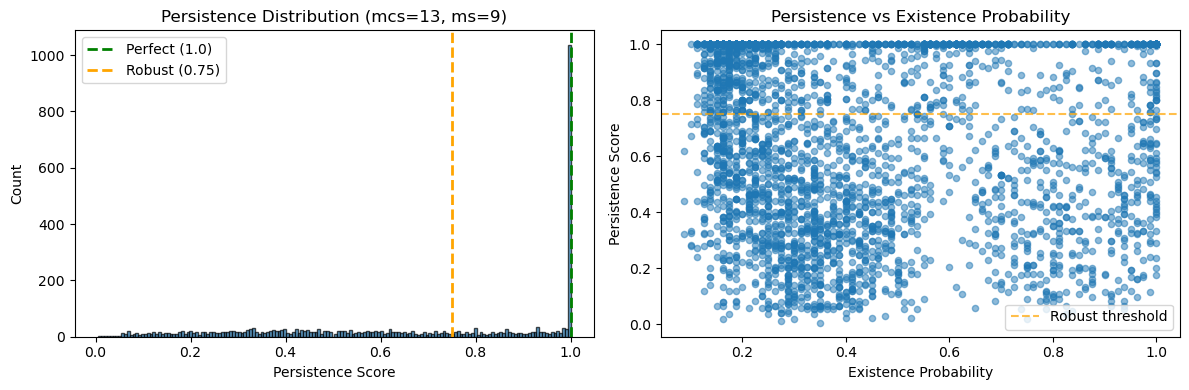


Persistence Summary (for mcs=13, ms=9):
  Total clusters: 3492
  Perfect (1.0): 1036 (29.7%)
  Robust (≥0.75): 1658 (47.5%)
  Fragile (<0.5): 1219 (34.9%)


In [11]:
# Compute persistence for all clusters in the largest run (instant lookup!)
largest_run_params = max(param_list, key=lambda p: len(runs[p]))
print(largest_run_params)
largest_run_params = (13,9)
largest_run = runs[largest_run_params]

print(f"Computing persistence for {len(largest_run)} clusters (using precomputed matches)...")

persistence_dict = compute_persistence_from_matches(
    largest_run_params, largest_run.keys(), all_matches, param_list
)

all_persistence = np.array([persistence_dict[cid] for cid in largest_run.keys()])
all_existence = np.array([largest_run[cid]['existence_prob'] for cid in largest_run.keys()])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(all_persistence, bins=len(runs)+1, edgecolor='black', alpha=0.7)
axes[0].axvline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
axes[0].axvline(0.75, color='orange', linestyle='--', linewidth=2, label='Robust (0.75)')
axes[0].set_xlabel('Persistence Score')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Persistence Distribution (mcs={largest_run_params[0]}, ms={largest_run_params[1]})')
axes[0].legend()

# Persistence vs existence probability
axes[1].scatter(all_existence, all_persistence, alpha=0.5, s=20)
axes[1].set_xlabel('Existence Probability')
axes[1].set_ylabel('Persistence Score')
axes[1].set_title('Persistence vs Existence Probability')
axes[1].axhline(0.75, color='orange', linestyle='--', alpha=0.7, label='Robust threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Summary stats
n_perfect = np.sum(all_persistence == 1.0)
n_robust = np.sum(all_persistence >= 0.75)
n_fragile = np.sum(all_persistence < 0.5)

print(f"\nPersistence Summary (for mcs={largest_run_params[0]}, ms={largest_run_params[1]}):")
print(f"  Total clusters: {len(all_persistence)}")
print(f"  Perfect (1.0): {n_perfect} ({100*n_perfect/len(all_persistence):.1f}%)")
print(f"  Robust (≥0.75): {n_robust} ({100*n_robust/len(all_persistence):.1f}%)")
print(f"  Fragile (<0.5): {n_fragile} ({100*n_fragile/len(all_persistence):.1f}%)")

## 4. Optimal Parameter Recommendation

In [12]:
# For each parameter setting, compute persistence for its own clusters (instant!)
param_scores = {}

for params in tqdm(param_list, desc="Evaluating parameter sets"):
    run_clusters = runs[params]
    persistence = compute_persistence_from_matches(params, run_clusters.keys(), all_matches, param_list)
    
    n_robust = sum(1 for p in persistence.values() if p >= 0.7)
    
    param_scores[params] = {
        'n_clusters': len(run_clusters),
        'n_robust': n_robust,
        'robust_fraction': n_robust / len(run_clusters) if len(run_clusters) > 0 else 0
    }

print("\nParameter Comparison:")
print("=" * 70)
print(f"{'mcs':>5} {'ms':>5} {'clusters':>10} {'robust':>10} {'robust_frac':>12}")
print("-" * 70)

for params in sorted(param_scores.keys()):
    s = param_scores[params]
    print(f"{params[0]:>5} {params[1]:>5} {s['n_clusters']:>10} {s['n_robust']:>10} {s['robust_fraction']:>12.1%}")

# Recommend: highest robust fraction, then most clusters as tiebreaker
best_params = max(param_scores.keys(), 
                  key=lambda p: (param_scores[p]['robust_fraction'], param_scores[p]['n_clusters']))

print(f"\n** RECOMMENDED: mcs={best_params[0]}, ms={best_params[1]} **")
print(f"   {param_scores[best_params]['n_clusters']} clusters, "
      f"{param_scores[best_params]['robust_fraction']:.1%} robust")

Evaluating parameter sets:   0%|          | 0/165 [00:00<?, ?it/s]


Parameter Comparison:
  mcs    ms   clusters     robust  robust_frac
----------------------------------------------------------------------
    4     5      12832       1496        11.7%
    4     6      10637       1579        14.8%
    4     7       9137       1642        18.0%
    4     8       7902       1698        21.5%
    4     9       7065       1741        24.6%
    4    10       6382       1790        28.0%
    4    11       5850       1816        31.0%
    4    12       5356       1819        34.0%
    4    13       5018       1815        36.2%
    4    14       4653       1794        38.6%
    4    15       4381       1764        40.3%
    4    16       4177       1736        41.6%
    4    18       3733       1606        43.0%
    4    19       3593       1523        42.4%
    4    20       3396       1447        42.6%
    5     5      10950       1492        13.6%
    5     6       9245       1571        17.0%
    5     7       7953       1668        21.0%
    5     8  

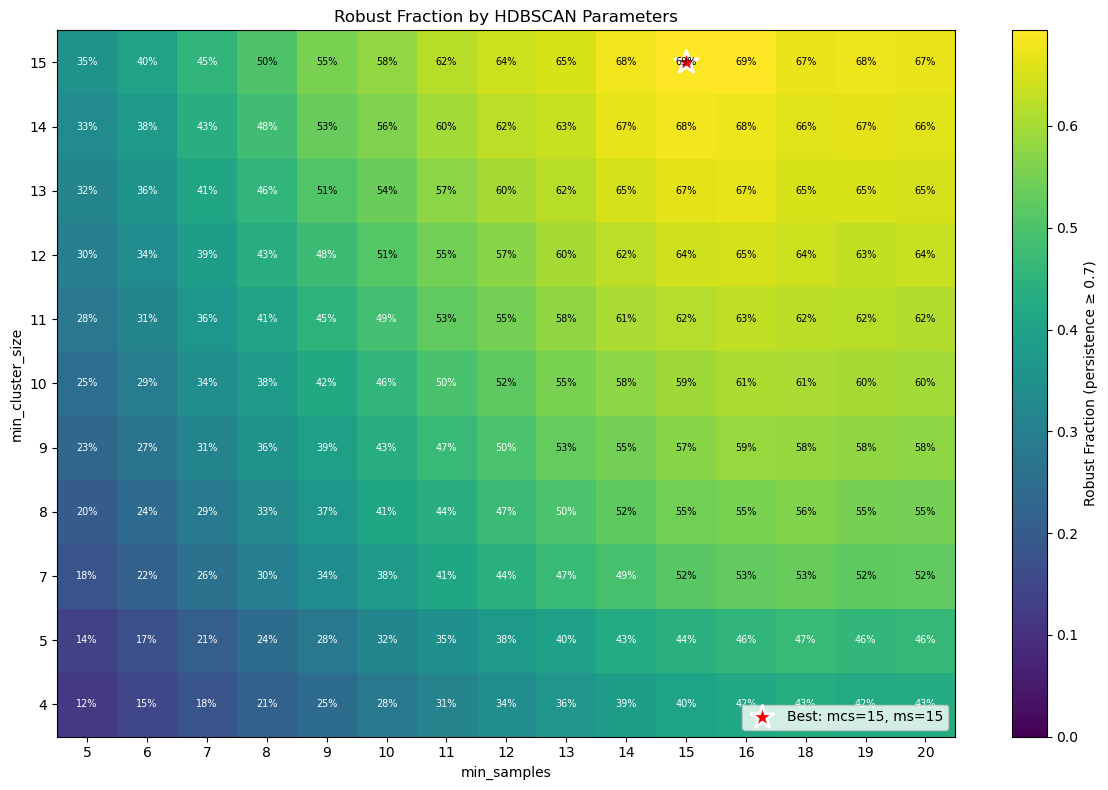

In [15]:
# 2D heatmap of mcs vs ms colored by robust_fraction
mcs_values = sorted(set(p[0] for p in param_scores.keys()))
ms_values = sorted(set(p[1] for p in param_scores.keys()))

# Build 2D grid
robust_grid = np.full((len(mcs_values), len(ms_values)), np.nan)

for (mcs, ms), scores in param_scores.items():
    i = mcs_values.index(mcs)
    j = ms_values.index(ms)
    robust_grid[i, j] = scores['robust_fraction']

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(robust_grid, cmap='viridis', aspect='auto', origin='lower',
               vmin=0, vmax=np.nanmax(robust_grid))

# Set ticks
ax.set_xticks(range(len(ms_values)))
ax.set_xticklabels(ms_values)
ax.set_yticks(range(len(mcs_values)))
ax.set_yticklabels(mcs_values)

ax.set_xlabel('min_samples')
ax.set_ylabel('min_cluster_size')
ax.set_title('Robust Fraction by HDBSCAN Parameters')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Robust Fraction (persistence ≥ 0.7)')

# Mark best params
best_i = mcs_values.index(best_params[0])
best_j = ms_values.index(best_params[1])
ax.scatter(best_j, best_i, marker='*', s=300, c='red', edgecolors='white', linewidths=2,
           label=f'Best: mcs={best_params[0]}, ms={best_params[1]}')
ax.legend(loc='lower right')

# Add text annotations for values
for i, mcs in enumerate(mcs_values):
    for j, ms in enumerate(ms_values):
        val = robust_grid[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.0%}', ha='center', va='center', fontsize=7, color=text_color)

plt.tight_layout()
plt.show()

## 5. Export Persistence Scores for Final Catalog

In [13]:
# Choose final parameters (use recommended or override)
FINAL_PARAMS = best_params  # or set manually, e.g., (12, 12)

final_clusters = runs[FINAL_PARAMS]

print(f"Computing persistence for final catalog (instant lookup)...")
final_persistence = compute_persistence_from_matches(
    FINAL_PARAMS, final_clusters.keys(), all_matches, param_list
)

print(f"\nFinal catalog: mcs={FINAL_PARAMS[0]}, ms={FINAL_PARAMS[1]}")
print(f"Clusters with persistence scores: {len(final_persistence)}")

# Summary
persistence_vals = np.array(list(final_persistence.values()))
print(f"\nPersistence distribution:")
print(f"  Perfect (1.0): {np.sum(persistence_vals == 1.0)}")
print(f"  Robust (≥0.7): {np.sum(persistence_vals >= 0.7)}")
print(f"  Moderate (0.5-0.7): {np.sum((persistence_vals >= 0.5) & (persistence_vals < 0.7))}")
print(f"  Fragile (<0.5): {np.sum(persistence_vals < 0.5)}")

print(f"\nTop 10 most robust clusters:")
for cid in sorted(final_persistence.keys(), key=lambda x: -final_persistence[x])[:10]:
    cdata = final_clusters[cid]
    print(f"  Cluster {cid}: persistence={final_persistence[cid]:.2f}, "
          f"exist_prob={cdata['existence_prob']:.2f}, mass={cdata['mean_m200_mass']:.2e}")

Computing persistence for final catalog (instant lookup)...

Final catalog: mcs=15, ms=15
Clusters with persistence scores: 2402

Persistence distribution:
  Perfect (1.0): 1018
  Robust (≥0.7): 1667
  Moderate (0.5-0.7): 236
  Fragile (<0.5): 499

Top 10 most robust clusters:
  Cluster 0: persistence=1.00, exist_prob=1.00, mass=1.71e+14
  Cluster 1: persistence=1.00, exist_prob=1.00, mass=1.64e+14
  Cluster 2: persistence=1.00, exist_prob=1.00, mass=1.56e+14
  Cluster 3: persistence=1.00, exist_prob=1.00, mass=9.63e+13
  Cluster 5: persistence=1.00, exist_prob=1.00, mass=1.07e+14
  Cluster 7: persistence=1.00, exist_prob=1.00, mass=2.20e+14
  Cluster 8: persistence=1.00, exist_prob=1.00, mass=1.07e+15
  Cluster 9: persistence=1.00, exist_prob=1.00, mass=1.25e+14
  Cluster 10: persistence=1.00, exist_prob=1.00, mass=1.53e+14
  Cluster 12: persistence=1.00, exist_prob=1.00, mass=1.69e+14


In [14]:
# Save persistence scores to the final HDF5 file
final_file = OUTPUT_DIR / f"hdbscan_clusters_mcs_{FINAL_PARAMS[0]}_ms_{FINAL_PARAMS[1]}.h5"

with h5py.File(final_file, 'r+') as f:
    # Add persistence scores to each cluster
    for cid, persistence in final_persistence.items():
        cluster_path = f'clusters/cluster_{cid}'
        if cluster_path in f:
            f[cluster_path].attrs['persistence_score'] = persistence
    
    # Add persistence metadata
    if 'persistence_analysis' in f:
        del f['persistence_analysis']
    pa = f.create_group('persistence_analysis')
    pa.attrs['n_parameter_runs'] = len(runs)
    pa.attrs['parameter_grid'] = str(list(runs.keys()))
    pa.attrs['overlap_threshold'] = OVERLAP_THRESHOLD
    pa.attrs['final_params'] = str(FINAL_PARAMS)

print(f"Saved persistence scores to {final_file}")

Saved persistence scores to ../output/hdbscan_clusters_mcs_15_ms_15.h5


## Summary

Each cluster now has a **persistence score** (0-1) indicating robustness across parameter choices:
- **1.0**: Appears in all parameter runs - definitely real
- **≥0.7**: Robust - appears in most runs
- **<0.5**: Fragile - parameter-dependent, treat with caution

Use `persistence_score` alongside `existence_prob` for filtering:
```python
# High-confidence clusters
robust = (persistence_score >= 0.7) & (existence_prob >= 0.5)
```